In [15]:
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Find the CSV file
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

# Load into pandas Dataframe
df = pd.read_csv(csv_path)

Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [16]:
from sklearn.preprocessing import LabelEncoder

# Use categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Empty dictionary to store encoders and mappings
label_encoders = {}

# Encode categorical columns and show mappings
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

    # Display mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding for column '{col}': {mapping}")

# Drop rows with missing values
df = df.dropna()

# Separate features and target
X = df.drop(columns=['id', 'stroke'])  # drop id and target column
y = df['stroke'].values.astype(int)

print(X)
print(X.shape)
print(y)
print(y.shape)

Encoding for column 'gender': {'Female': 0, 'Male': 1, 'Other': 2}
Encoding for column 'ever_married': {'No': 0, 'Yes': 1}
Encoding for column 'work_type': {'Govt_job': 0, 'Never_worked': 1, 'Private': 2, 'Self-employed': 3, 'children': 4}
Encoding for column 'Residence_type': {'Rural': 0, 'Urban': 1}
Encoding for column 'smoking_status': {'Unknown': 0, 'formerly smoked': 1, 'never smoked': 2, 'smokes': 3}
      gender   age  hypertension  heart_disease  ever_married  work_type  \
0          1  67.0             0              1             1          2   
2          1  80.0             0              1             1          2   
3          0  49.0             0              0             1          2   
4          0  79.0             1              0             1          3   
5          1  81.0             0              0             1          2   
...      ...   ...           ...            ...           ...        ...   
5104       0  13.0             0              0           

In [17]:
def classification_impurity(labels):
    # Compute classification impurity (misclassification rate) of the data with labels.
    if len(labels) == 0:
        return 0
    _, counts = np.unique(labels, return_counts=True)
    max_prob = np.max(counts) / len(labels)
    return 1 - max_prob

In [18]:
def compute_information_gain(data, feature_index, labels):
    initial_impurity = classification_impurity(labels)
    distinct_values = np.unique(data[:, feature_index])

    highest_info_gain = -1
    split_threshold = None

    for i in range(1, len(distinct_values)):
        threshold = (distinct_values[i-1] + distinct_values[i]) / 2
        left_split = data[:, feature_index] <= threshold
        right_split = data[:, feature_index] > threshold
        left_labels = labels[left_split]
        right_labels = labels[right_split]

        left_impurity = classification_impurity(left_labels)
        right_impurity = classification_impurity(right_labels)

        weighted_impurity = (len(left_labels)/len(labels)) * left_impurity + (len(right_labels)/len(labels)) * right_impurity
        info_gain = initial_impurity - weighted_impurity

        if info_gain > highest_info_gain:
            highest_info_gain = info_gain
            split_threshold = threshold

    return highest_info_gain, split_threshold

In [19]:
import numpy as np

data = np.array([[1, 0], [1, 1], [0, 1], [0, 0]])
labels = np.array([0, 1, 1, 0])
info_gain, threshold=compute_information_gain(data, 0, labels)
assert np.isclose(info_gain, 0.0, atol=0.01)


In [20]:
def best_split(data, labels):
    best_info_gain = -1
    best_feature = None
    best_threshold = None
    for feature_index in range(data.shape[1]):
        info_gain, threshold = compute_information_gain(data, feature_index, labels)
        if info_gain > best_info_gain:
            best_info_gain = info_gain
            best_feature = feature_index
            best_threshold = threshold
    return best_feature, best_threshold

In [21]:
class DecisionTreeNode:
    """Class for a decision tree node."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.root = None

    def fit(self, data, labels, depth=0):
        """Recursively builds the decision tree."""
        # Base case: Stop splitting if pure or max depth reached
        if depth == self.max_depth or len(np.unique(labels)) == 1: #Why?
        # Answer: If the max depth of the tree is reached or if the split is pure (having only 1 unique label), then the splitting is to be stopped
            return DecisionTreeNode(value=np.bincount(labels).argmax()) #Why?
            # Answer: Finding out the maxium occuring label in the node of the tree then defining with the node so we can predict it

        # Find best feature and threshold
        best_feature, best_threshold = best_split(data, labels)

        # Partition data
        left_mask = data[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        if np.all(left_mask) or np.all(right_mask):  # Prevent infinite splitting
            return DecisionTreeNode(value=np.bincount(labels).argmax())

        left_child = self.fit(data[left_mask], labels[left_mask], depth + 1)
        right_child = self.fit(data[right_mask], labels[right_mask], depth + 1)

        return DecisionTreeNode(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def train(self, data, labels):
        """Initialize tree training."""
        self.root = self.fit(data, labels, depth=0)



In [22]:
def predict_sample(node, sample):
    """Recursively predict the label for a single sample."""
    if node.value is not None:
        return node.value
    if sample[node.feature] <= node.threshold:
        return predict_sample(node.left, sample)
    else:
        return predict_sample(node.right, sample)

def predict(tree, data):
    """Predict labels for multiple samples."""
    return np.array([predict_sample(tree.root, sample) for sample in data])


      gender   age  hypertension  heart_disease  ever_married  work_type  \
0          1  67.0             0              1             1          2   
2          1  80.0             0              1             1          2   
3          0  49.0             0              0             1          2   
4          0  79.0             1              0             1          3   
5          1  81.0             0              0             1          2   
...      ...   ...           ...            ...           ...        ...   
5104       0  13.0             0              0             0          4   
5106       0  81.0             0              0             1          3   
5107       0  35.0             0              0             1          3   
5108       1  51.0             0              0             1          2   
5109       0  44.0             0              0             1          0   

      Residence_type  avg_glucose_level   bmi  smoking_status  
0                  1   

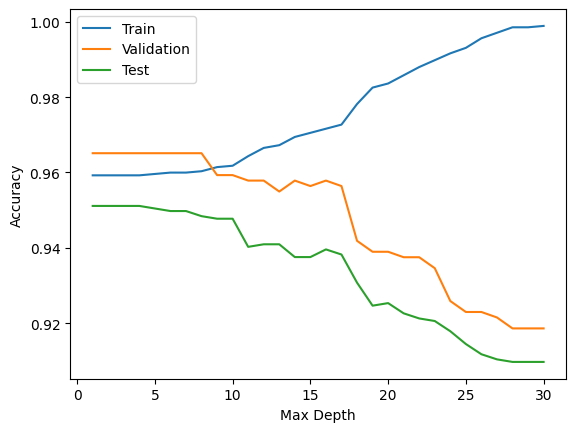

In [23]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print(X)
X_np = X.to_numpy()  # Convert DataFrame to NumPy array
print(X)
X_train, X_test, y_train, y_test = train_test_split(X_np, y, test_size=0.3, random_state=42)


print(X_train.shape, X_test.shape)  # Check dataset shape

# Train the decision tree
tree = DecisionTree(max_depth=5)
tree.train(X_train, y_train)

# Make predictions
y_pred = predict(tree, X_test)

# Evaluate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2f}")


# Spliting data into train and validation data sets
X1_train,X_val,y1_train,y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)


y_train_pred = predict(tree, X1_train)
training_accuracy = np.mean(y_train_pred == y1_train)
print(f"Train Accuracy: {training_accuracy:.2f}")


# Finding accuracy
y_val_pred = predict(tree, X_val)
validation_accuracy = np.mean(y_val_pred == y_val)
print(f"Validation Accuracy: {validation_accuracy:.2f}")



# Plotting acurracies while changing max depth from 1 to 30
train_accuracies = []# initiallizing lists
val_accuracies = []
test_accuracies = []
depth_range = range(1,31)
for depth in depth_range:# looping through max depths from 1 to 30
  tree = DecisionTree(max_depth=depth)
  tree.train(X1_train, y1_train)

  y_train_pred = predict(tree, X1_train)# making predictions
  y_val_pred = predict(tree, X_val)
  y_test_pred = predict(tree, X_test)

  train_accuracies.append(np.mean(y_train_pred == y1_train))# finding accuracies
  val_accuracies.append(np.mean(y_val_pred == y_val))
  test_accuracies.append(np.mean(y_test_pred == y_test))

plt.plot(depth_range, train_accuracies, label='Train')# plotting
plt.plot(depth_range, val_accuracies, label='Validation')
plt.plot(depth_range, test_accuracies, label='Test')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Dimensionality Reduction with pca

--> PCA with 10 components:
Test Accuracy: 0.937
F1 Score:      0.041


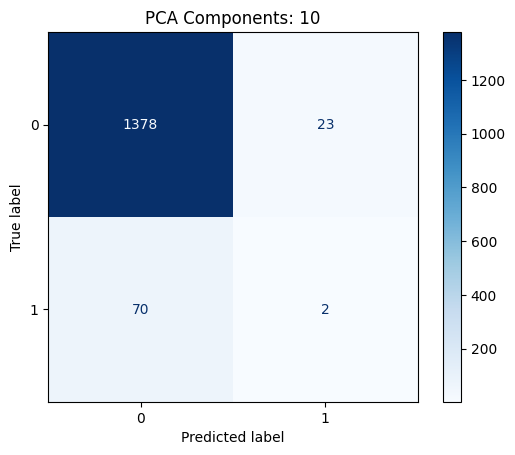

--> PCA with 9 components:
Test Accuracy: 0.938
F1 Score:      0.042


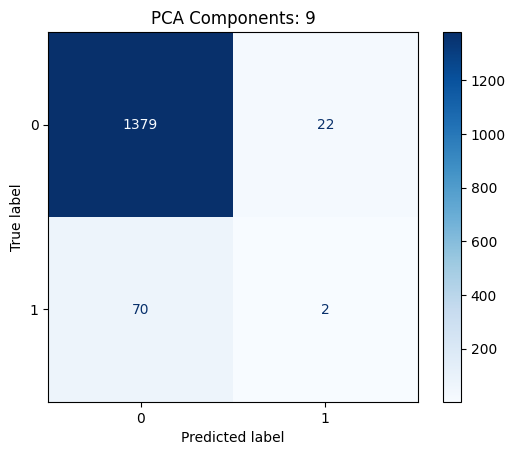

--> PCA with 8 components:
Test Accuracy: 0.944
F1 Score:      0.068


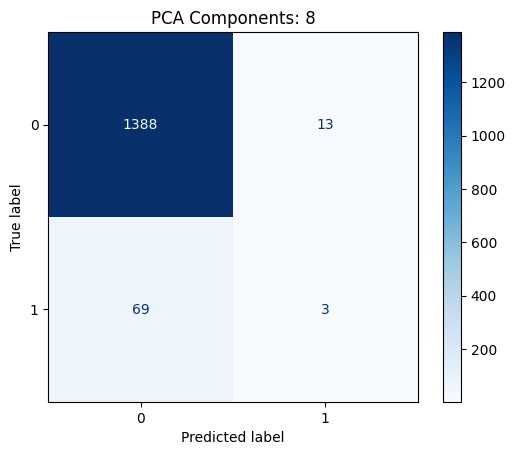

--> PCA with 7 components:
Test Accuracy: 0.946
F1 Score:      0.048


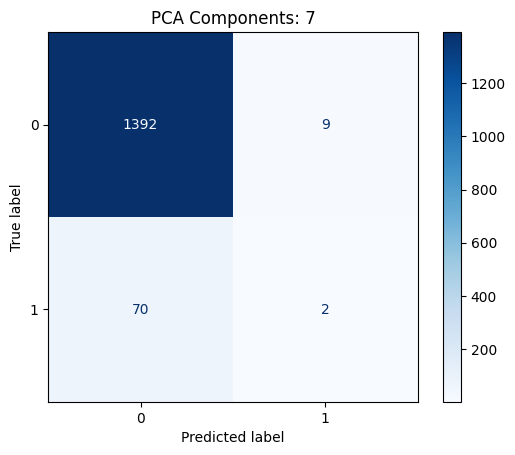

--> PCA with 6 components:
Test Accuracy: 0.947
F1 Score:      0.049


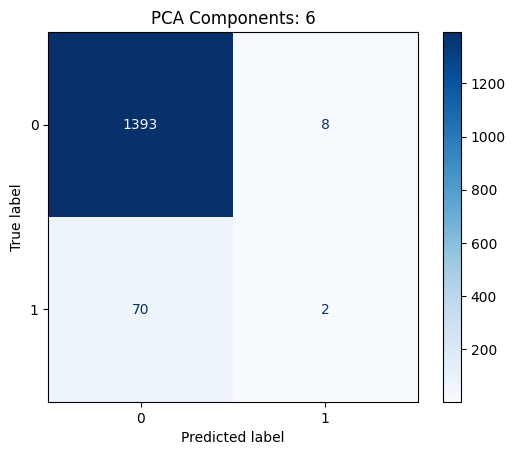

--> PCA with 5 components:
Test Accuracy: 0.947
F1 Score:      0.049


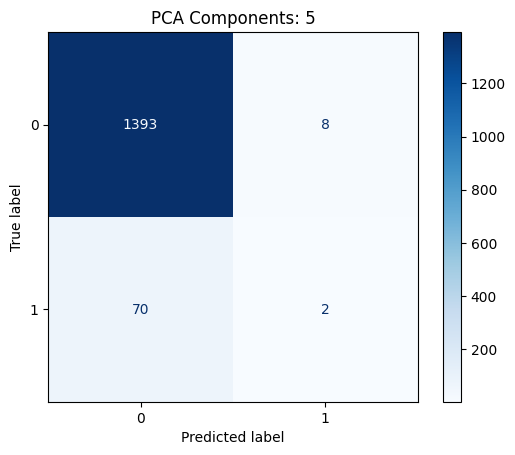

--> PCA with 4 components:
Test Accuracy: 0.946
F1 Score:      0.048


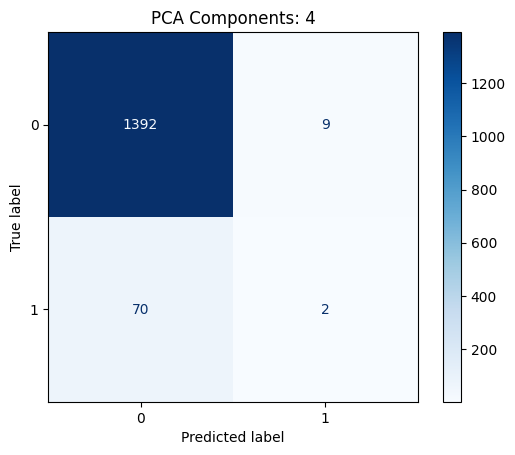

--> PCA with 3 components:
Test Accuracy: 0.946
F1 Score:      0.000


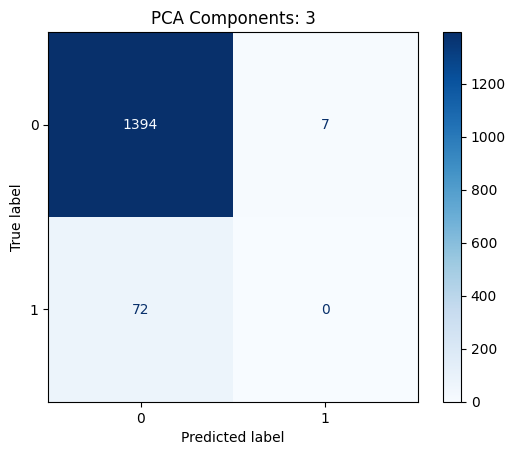

--> PCA with 2 components:
Test Accuracy: 0.950
F1 Score:      0.000


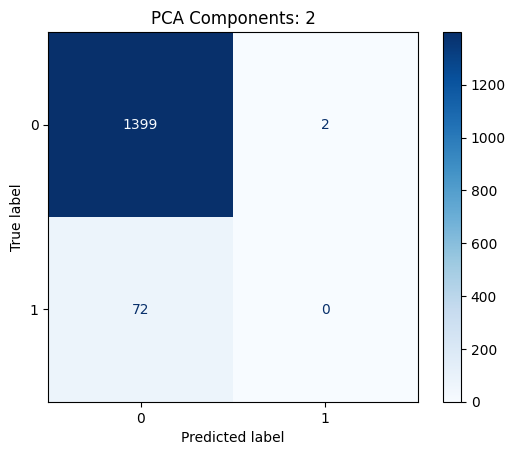

--> PCA with 1 components:
Test Accuracy: 0.951
F1 Score:      0.000


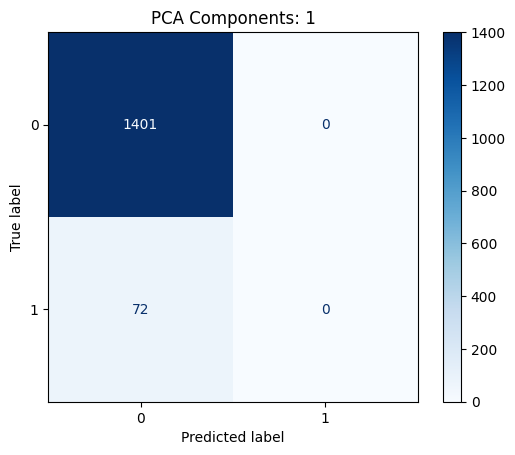

In [25]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

original_dim = X_np.shape[1]

print("Dimensionality Reduction with pca\n")

for dim in range(original_dim, 0, -1):
    print(f"--> PCA with {dim} components:")

    # Apply PCA
    pca = PCA(n_components=dim)
    X_pca = pca.fit_transform(X_np)

    # Split data
    X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)

    # Train the decision tree
    tree_pca = DecisionTree(max_depth=10)
    tree_pca.train(X_train_pca, y_train_pca)

    # Predict
    y_test_pred_pca = predict(tree_pca, X_test_pca)

    # Accuracy
    test_acc = np.mean(y_test_pred_pca == y_test_pca)

    # F1 Score (binary classification assumed)
    f1 = f1_score(y_test_pca, y_test_pred_pca)

    # Print scores
    print(f"Test Accuracy: {test_acc:.3f}")
    print(f"F1 Score:      {f1:.3f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test_pca, y_test_pred_pca)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"PCA Components: {dim}")
    plt.show()
